In [142]:
import warnings 
warnings.filterwarnings("ignore")

In [140]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

In [9]:
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6, 7, 8, 9, 8, 9, 9, 8])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7, 1, 2, 1, 2, 3, 2, 3])

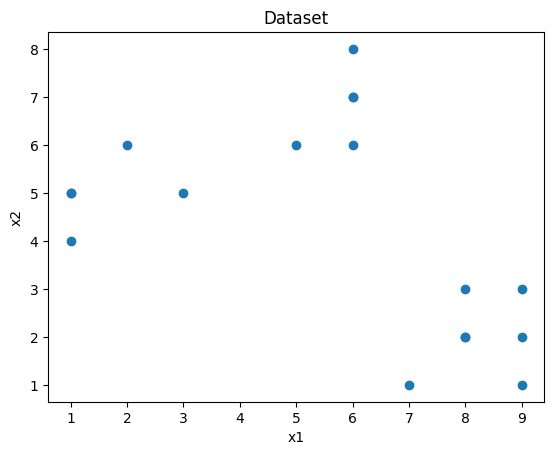

In [13]:
plt.scatter(x1,x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset")
plt.show()

In [19]:
X = np.array(list(zip(x1,x2)))

In [21]:
X

array([[3, 5],
       [1, 4],
       [1, 5],
       [2, 6],
       [1, 5],
       [6, 8],
       [6, 6],
       [6, 7],
       [5, 6],
       [6, 7],
       [7, 1],
       [8, 2],
       [9, 1],
       [8, 2],
       [9, 3],
       [9, 2],
       [8, 3]])

In [27]:
kmeans_m = KMeans(n_clusters=2,random_state=0).fit(X)

In [29]:
kmeans_m

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [33]:
k_2_centroid = kmeans_m.cluster_centers_

In [53]:
k_2_centroid[0]

array([3.7, 5.9])

In [55]:
k_2_centroid[1]

array([8.28571429, 2.        ])

In [41]:
x1_c_0 = k_2_centroid[0][0]
x2_c_0 = k_2_centroid[0][1]

In [43]:
x1_c_1 = k_2_centroid[1][0]
x2_c_1 = k_2_centroid[1][1]

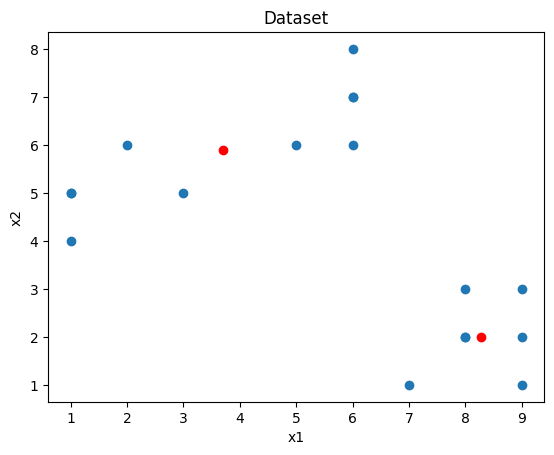

In [47]:
plt.scatter(x1,x2)
plt.scatter(x1_c_0,x2_c_0,c='r')
plt.scatter(x1_c_1,x2_c_1,c='r')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset")
plt.show()

In [65]:
X.shape

(17, 2)

In [89]:
sum(np.min(cdist(X,k_2_centroid),axis=1))/X.shape[0]

1.7687413573405673

In [61]:
np.array(k_2_centroid[0])

array([3.7, 5.9])

In [85]:
distance = []
K = range(1,10)
for k in K:
    kmeans_m = KMeans(n_clusters=k,random_state=0).fit(X)
    distance.append(sum(np.min(cdist(X,kmeans_m.cluster_centers_),axis=1))/X.shape[0])

In [87]:
distance

[3.4577032384495707,
 1.7687413573405673,
 0.8819889697423957,
 0.8065852008780326,
 0.7239442260134706,
 0.6026238181316149,
 0.5293957542883456,
 0.39691452327684873,
 0.3306811143884747]

In [81]:
list(K)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

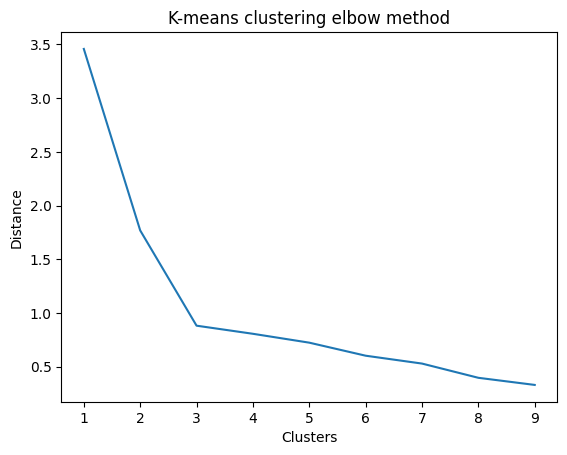

In [102]:
plt.plot(K,distance)
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.title("K-means clustering elbow method")
plt.show()

In [104]:
kmeans_m = KMeans(n_clusters=3,random_state=0).fit(X)

In [112]:
kmeans_m.cluster_centers_

array([[5.8       , 6.8       ],
       [8.28571429, 2.        ],
       [1.6       , 5.        ]])

In [106]:
kmeans_m.labels_

array([2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [108]:
kmeans_m.predict([[2,2],[9,4],[5,7]])

array([2, 1, 0], dtype=int32)

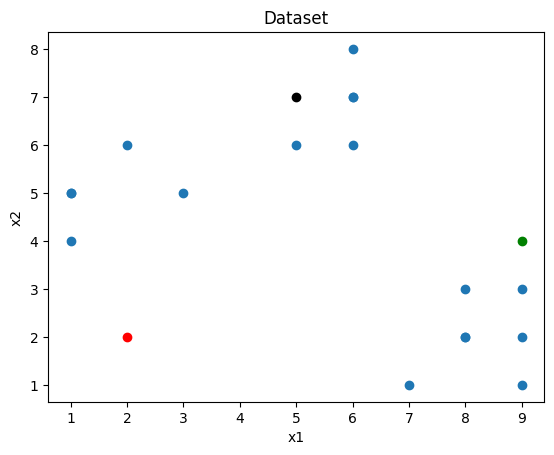

In [110]:
plt.scatter(x1,x2)
plt.scatter(2,2,c='r')
plt.scatter(9,4,c='g')
plt.scatter(5,7,c='k')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset")
plt.show()

## Hierarchical Clustering

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.datasets import make_blobs,make_circles

In [154]:
# make_blobs??

In [20]:
X, _ = make_blobs(n_samples=10, centers=3, n_features=2,random_state=10)

In [22]:
X

array([[  5.69192445,  -9.47641249],
       [  1.70789903,   6.00435173],
       [  0.23621041,  -3.11909976],
       [  2.90159483,   5.42121526],
       [  5.85943906,  -8.38192364],
       [  6.04774884, -10.30504657],
       [ -2.00758803,  -7.24743939],
       [  1.45467725,  -6.58387198],
       [  1.53636249,   5.11121453],
       [  5.4307043 ,  -9.75956122]])

In [24]:
X[:,0]

array([ 5.69192445,  1.70789903,  0.23621041,  2.90159483,  5.85943906,
        6.04774884, -2.00758803,  1.45467725,  1.53636249,  5.4307043 ])

In [26]:
y

array([0, 0, 1, 0, 2, 2, 2, 1, 1, 0])

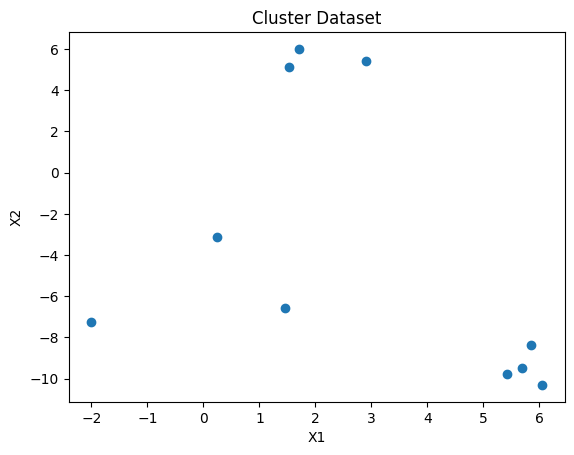

In [28]:
plt.scatter(X[:,0],X[:,1])
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Cluster Dataset")
plt.show()

In [152]:
# linkage??

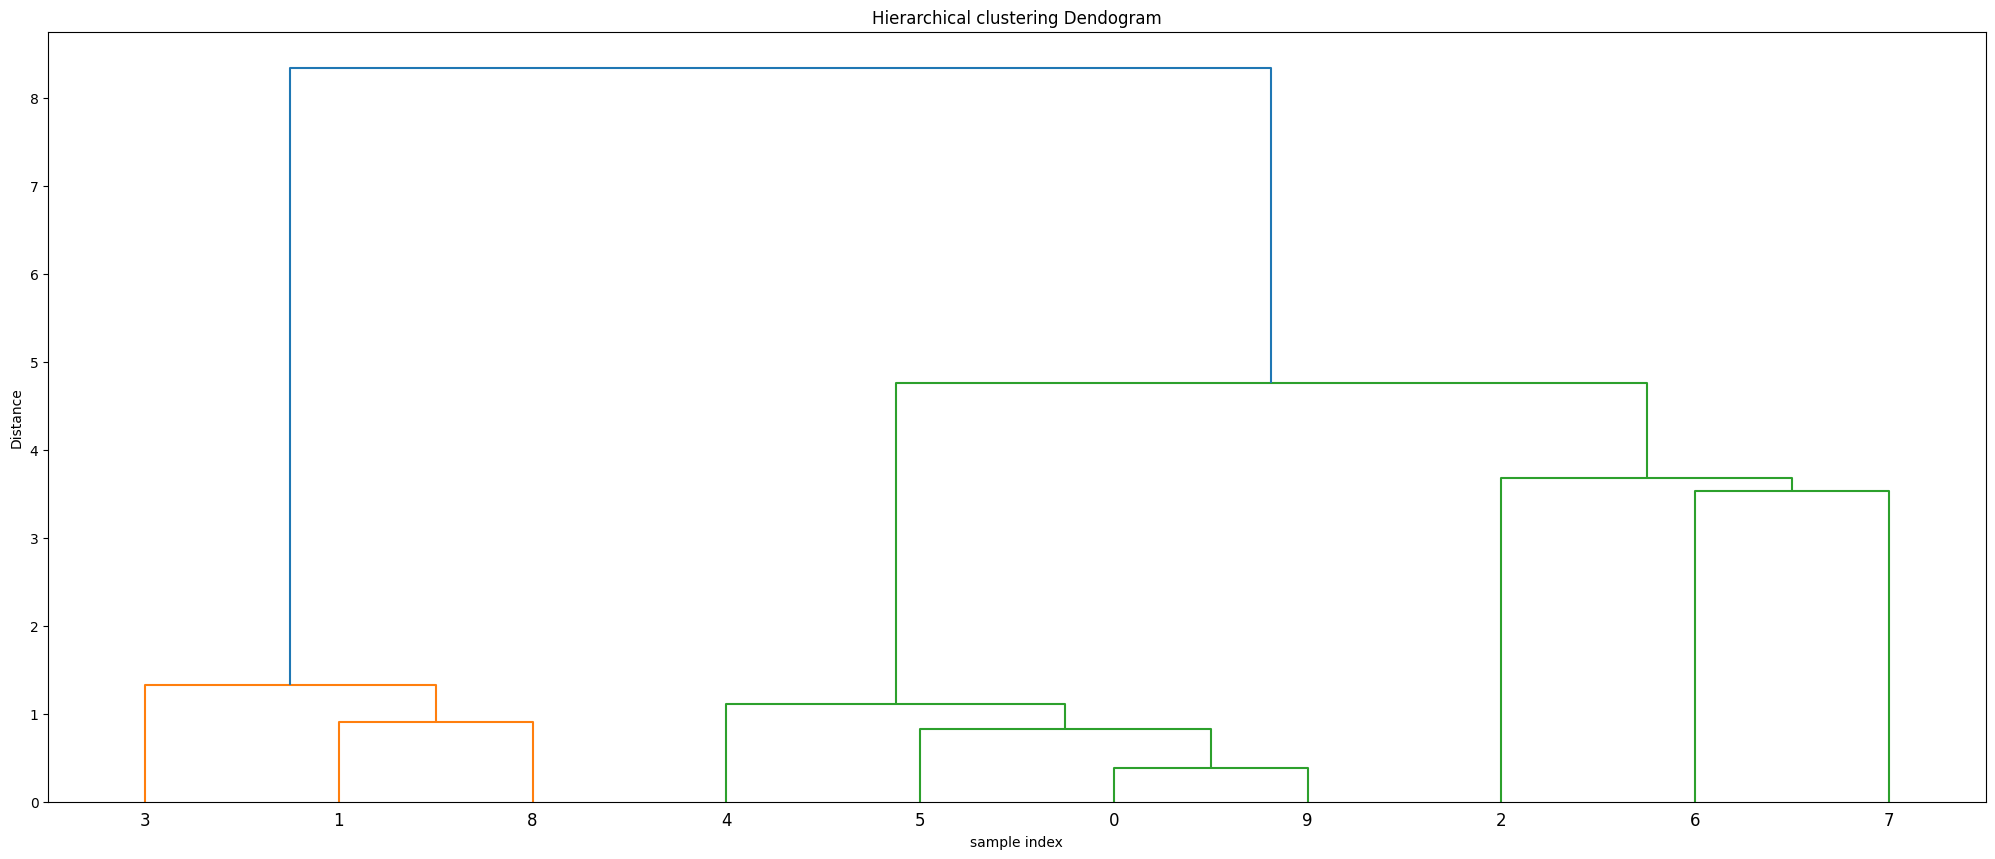

In [34]:
Z = linkage(X)
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.xlabel("sample index")
plt.ylabel("Distance")
plt.title("Hierarchical clustering Dendogram")
plt.show()

## DBSCAN : Density Based spatial clustering of Applications with Noise

In [38]:
from sklearn.cluster import DBSCAN

In [150]:
# make_circles??

In [94]:
X, _ = make_circles(n_samples = 100, noise=0.05,factor=0.5, random_state=42)

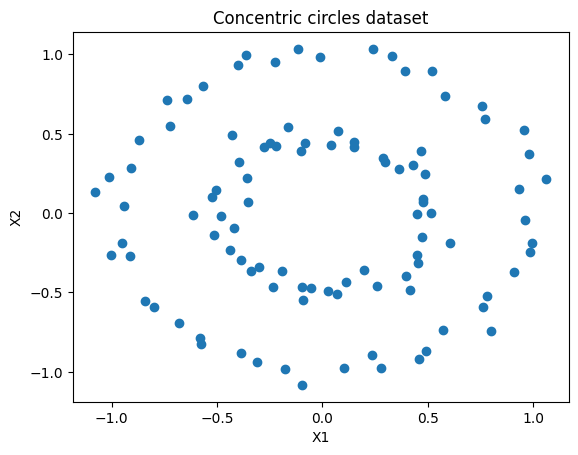

In [96]:
plt.scatter(X[:,0],X[:,1])
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Concentric circles dataset")
plt.show()

In [98]:
DBSCAN??

Init signature:
DBSCAN(
    eps=0.5,
    *,
    min_samples=5,
    metric='euclidean',
    metric_params=None,
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None,
)
Source:        
class DBSCAN(ClusterMixin, BaseEstimator):
    """Perform DBSCAN clustering from vector array or distance matrix.

    DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
    Finds core samples of high density and expands clusters from them.
    This algorithm is particularly good for data which contains clusters of
    similar density and can find clusters of arbitrary shape.

    Unlike K-means, DBSCAN does not require specifying the number of clusters
    in advance and can identify outliers as noise points.

    This implementation has a worst case memory complexity of :math:`O({n}^2)`,
    which can occur when the `eps` param is large and `min_samples` is low,
    while the original DBSCAN only uses linear memory.
    For further details, see the Notes below.

    Read

In [130]:
dbscan = DBSCAN(eps=0.2,min_samples=5)
clustering = dbscan.fit(X)

In [132]:
labels = clustering.labels_

In [134]:
labels

array([ 0,  0,  0, -1, -1, -1, -1,  0, -1, -1, -1, -1,  0, -1,  0, -1,  0,
        0, -1, -1,  0,  0, -1, -1,  0, -1, -1,  0, -1,  0, -1, -1,  0, -1,
        0, -1,  0,  0, -1, -1, -1, -1, -1,  0, -1, -1,  0, -1,  0, -1, -1,
       -1, -1, -1, -1,  0, -1,  0, -1,  0,  0,  0,  0, -1,  0,  0, -1,  0,
        0,  0,  0, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0, -1, -1, -1,
        0, -1, -1, -1,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,  0])

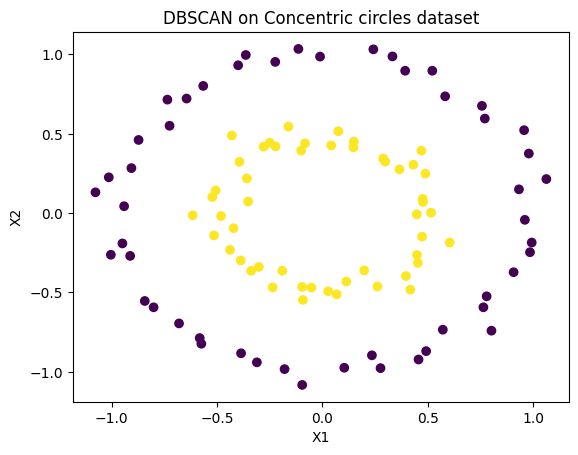

In [136]:
plt.scatter(X[:,0],X[:,1],c=labels)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("DBSCAN on Concentric circles dataset")
plt.show()

In [144]:
kmeans_cc = KMeans(n_clusters=2,random_state=0).fit(X)

In [146]:
labels = kmeans_cc.labels_

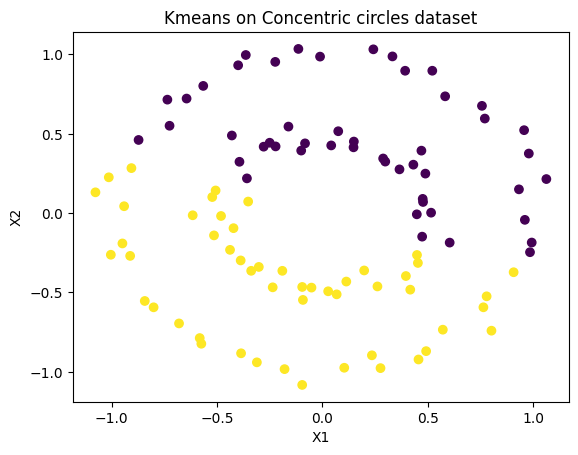

In [148]:
plt.scatter(X[:,0],X[:,1],c=labels)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Kmeans on Concentric circles dataset")
plt.show()

In [156]:
distance = []
K = range(1,10)
for k in K:
    kmeans_cc = KMeans(n_clusters=k,random_state=0).fit(X)
    distance.append(sum(np.min(cdist(X,kmeans_cc.cluster_centers_),axis=1))/X.shape[0])

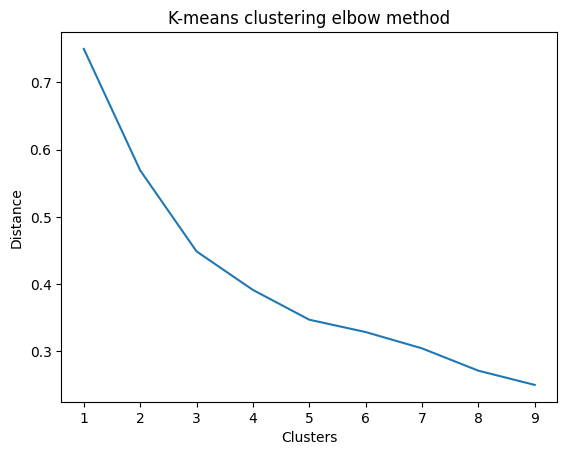

In [158]:
plt.plot(K,distance)
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.title("K-means clustering elbow method")
plt.show()